In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Parameters of the SDOF torsional system
I = 0.1  # Inertia in [kg*m^2]
c = 10   # Torsional stiffness in [N*m/rad]

In [36]:
class SDOFTorsionalSystem:

    # Constructor to initialize the system parameters
    def __init__(self, inertia=0, stiffness=0):
        self.I = inertia
        self.c = stiffness
        if self.I > 0 and self.c > 0:
            self.omega_n = self.calculate_natural_frequency()
        else:
            self.omega_n = None

    # Method to calculate the natural frequency of the system
    def calculate_natural_frequency(self):
        return np.sqrt(self.c / self.I)

     # Method to simulate the time response of the system
    # NOTE: modified to account for harmonic excitation
    def simulate_time_response(self, initial_angle=0, initial_velocity=0, time_span=10, load_type="constant", tau_ext=0):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertia and stiffness.")
        
        # Time array
        t = np.linspace(0, time_span, 1000)
        # Natural frequency
        omega_n = self.omega_n
        if load_type == "constant":
             tau_0 = tau_ext
             thetaP_0 = tau_0 / self.c
             thetaP_t = thetaP_0 * np.ones_like(t)  # Particular solution for constant torque
             thetaPdot_0 = 0
        elif load_type == "linear":
            r = tau_ext
            alpha = r / self.c
            beta = 0
            thetaP_t = alpha * t + beta  # Particular solution for linear torque ramp
            thetaP_0 = thetaP_t[0]  # Initial value of the particular solution at t=0
            thetaPdot_0 = r / self.c  # Initial value of the derivative of the particular solution at t=0
        elif load_type == "harmonic":
            tau_0 = tau_ext['amplitude']
            omega_f = tau_ext['frequency'] * 2 * np.pi  # Convert frequency from Hz to rad/s
            A_P = tau_0 / (self.c - self.I * omega_f**2)
            B_P = 0
            thetaP_t = A_P * np.sin(omega_f * t) + B_P * np.cos(omega_f * t)  # Particular solution for harmonic excitation
            thetaP_0 = thetaP_t[0]  # Initial value of the particular solution at t=0
            thetaPdot_0 = A_P * omega_f * np.cos(omega_f * t)[0]  # Initial value of the derivative of the particular solution at t=0
        else:
            raise ValueError("Unsupported load type. Please specify 'constant' for constant external torque, 'linear' for linear torque ramp, or 'harmonic' for harmonic excitation.")
        
        # Calculate the constants A and B based on initial conditions
        A = initial_angle - thetaP_0  # Adjusting for the particular solution at t=0
        B = (initial_velocity - thetaPdot_0) / omega_n  # Adjusting for the derivative of the particular solution at t=0
        # General solution for the homogeneous part
        thetaG_t = A * np.cos(omega_n * t) + B * np.sin(omega_n * t)
        # Time response using the analytical solution for the specified load type
        theta_t = thetaG_t + thetaP_t
        return t, theta_t

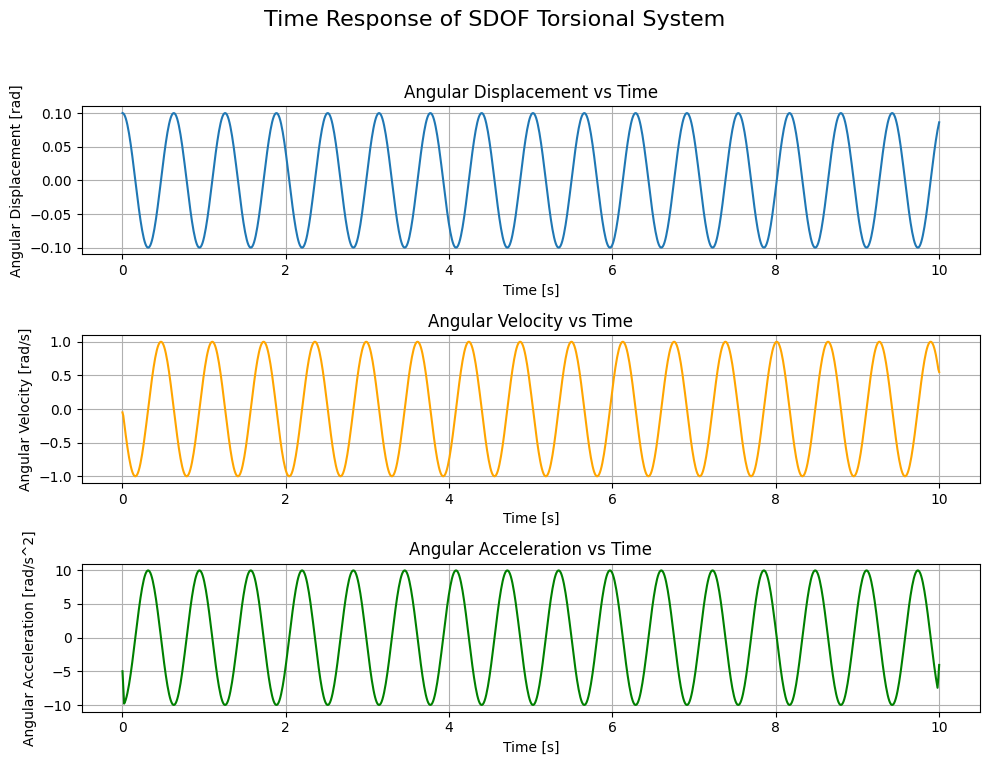

In [38]:
# Create an instance of the SDOF torsional system
S = SDOFTorsionalSystem(inertia=I, stiffness=c)

# Initial conditions
initial_angle = 0.1  # Initial angular displacement in [rad]
initial_velocity = 0.0  # Initial angular velocity in [rad/s]

# Simulate time response
time_span = 10  # Time span for simulation in [s]
t, theta_t = S.simulate_time_response(initial_angle=initial_angle, initial_velocity=initial_velocity, time_span=time_span)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

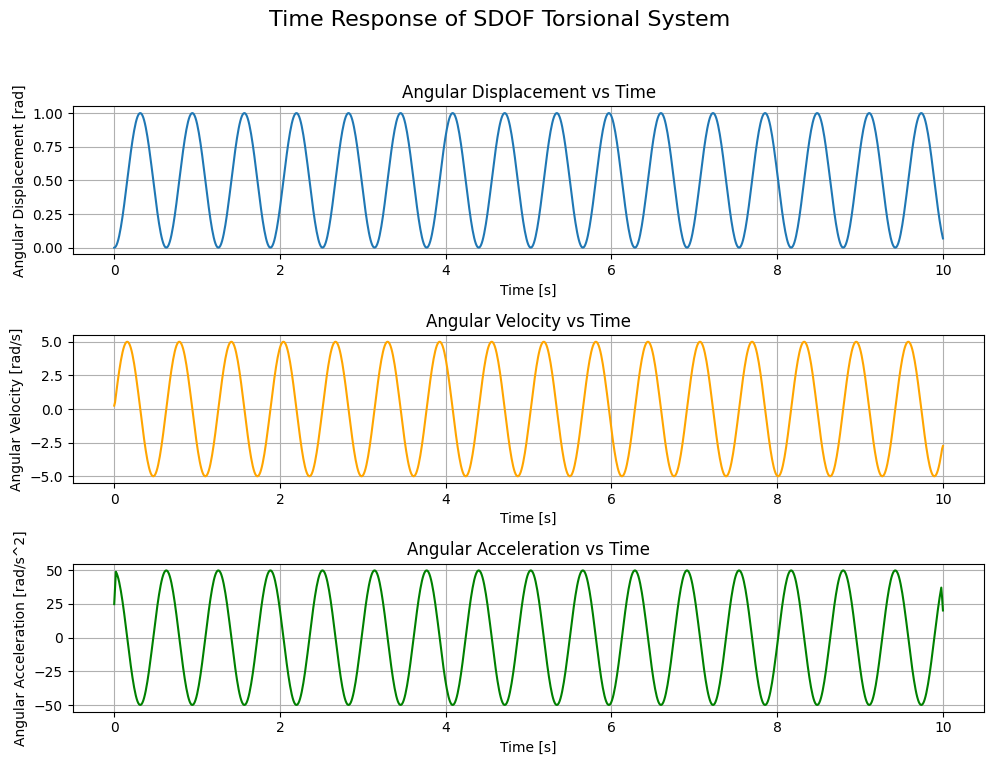

In [39]:
# Simulate time response with a constant external torque
tau_ext = 5  # Constant external torque in [N*m]
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=time_span, load_type="constant", tau_ext=tau_ext)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

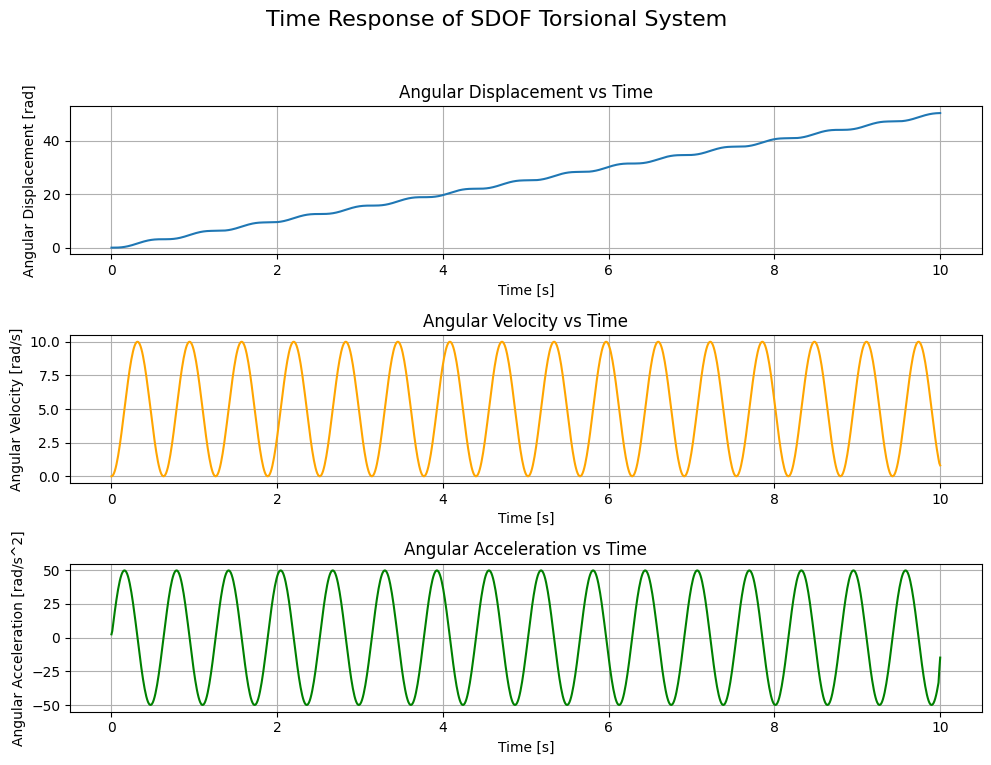

In [40]:
# Simulate time response with a linear torque ramp
tau_ext = 50  # Rate of change of the torque in [N*m/s]
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=time_span, load_type="linear", tau_ext=tau_ext)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

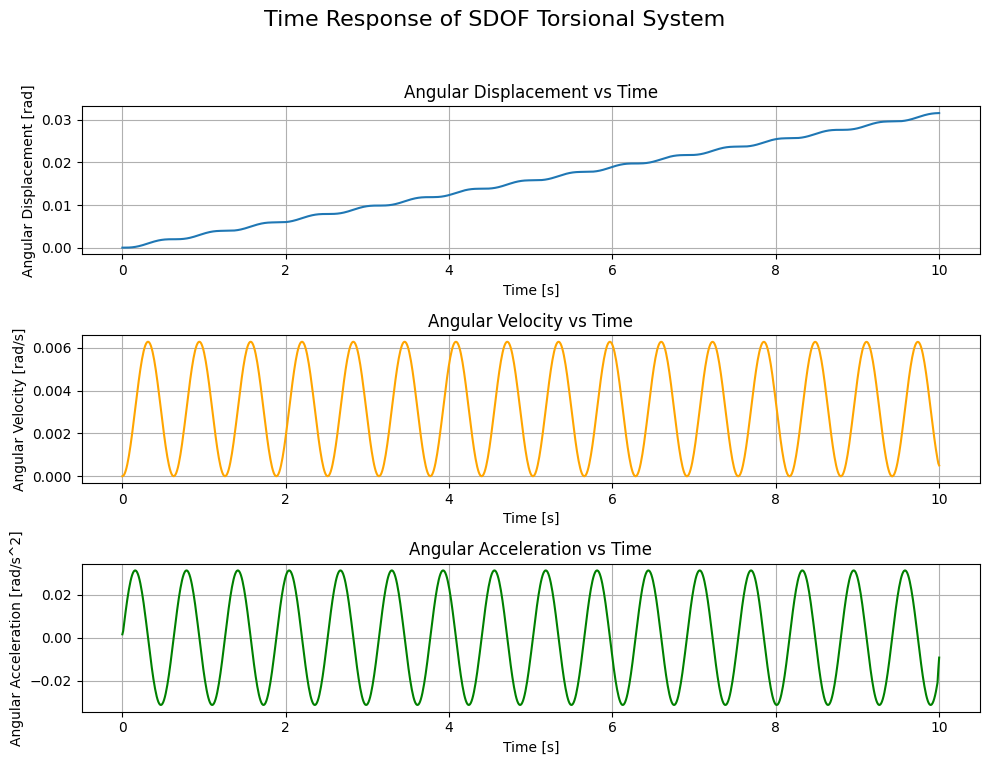

In [79]:
# Simulate time response with a harmonic excitation
tau_0 = 5  # Amplitude of the harmonic excitation in [N*m]
f_excitation = 1e-3#10/2/np.pi-1e-3  # Frequency of the harmonic excitation in [Hz]
tau_ext = {'amplitude': tau_0, 'frequency': f_excitation}
t, theta_t = S.simulate_time_response(initial_angle=0, initial_velocity=0, time_span=10, load_type="harmonic", tau_ext=tau_ext)

# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t, theta_t, label='Angular Displacement')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t)
axes[1].plot(t, angular_velocity, label='Angular Velocity', color='orange')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])